# Phase 4: Quantization Analysis

This notebook analyzes the results of int8 quantization (PTQ and QAT) applied to
three neural network architectures (M2, M5, M6) across three taxonomy tiers.

**Prerequisites:** Run `python src/quantize_nn.py` to generate all quantized models and results.

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120

PROJECT_ROOT = Path('..').resolve()
RESULTS_DIR = PROJECT_ROOT / 'results'

# Load results
with open(RESULTS_DIR / 'quantization_results.json') as f:
    results = json.load(f)

df = pd.read_csv(RESULTS_DIR / 'quantization_summary.csv')
print(f'Loaded {len(df)} quantized model evaluations')
df.head()

Loaded 18 quantized model evaluations


,model,tier,method,condition,f32_accuracy,f32_f1_macro,int8_accuracy,int8_f1_macro,delta_accuracy,delta_f1_macro,agreement_rate,mcnemar_p,tflite_size_kb
0,m2,1,ptq,combined,0.9135,0.8975,0.9135,0.8975,0.0000,0.0000,0.9904,0.4795,19.9
1,m2,1,qat,combined,0.9135,0.8975,0.8990,0.8799,0.0144,0.0176,0.9663,0.4497,20.3
2,m2,2,ptq,combined,0.8654,0.7438,0.8654,0.7413,0.0000,0.0025,0.9904,1.0000,20.1
3,m2,2,qat,combined,0.8654,0.7438,0.8702,0.7426,-0.0048,0.0012,0.9567,1.0000,20.5
4,m2,3,ptq,combined,0.7832,0.7288,0.7832,0.7288,0.0000,0.0000,1.0000,1.0000,20.3


## 1. Master Comparison Table

Float32 baselines alongside all int8 variants, organized by tier.

In [2]:
# Build master comparison table
model_names = {'m2': '2-D CNN (M2)', 'm5': '1-D CNN (M5)', 'm6': 'DS-CNN (M6)'}

for tier in [1, 2, 3]:
    print(f'\n{"=" * 80}')
    print(f'  Tier {tier}')
    print(f'{"=" * 80}')
    
    tier_df = df[df['tier'] == tier].copy()
    tier_df['display'] = tier_df['model'].map(model_names)
    
    print(f'{"Model":<20} {"Method":<6} {"F32 Acc":>8} {"F32 F1m":>8} {"Int8 Acc":>9} {"Int8 F1m":>9} {"dAcc":>7} {"dF1m":>7} {"Agree":>7} {"Size(KB)":>9}')
    print('-' * 95)
    for _, row in tier_df.iterrows():
        print(f'{model_names[row["model"]]:<20} {row["method"].upper():<6} '
              f'{row["f32_accuracy"]:>8.4f} {row["f32_f1_macro"]:>8.4f} '
              f'{row["int8_accuracy"]:>9.4f} {row["int8_f1_macro"]:>9.4f} '
              f'{row["delta_accuracy"]:>+7.4f} {row["delta_f1_macro"]:>+7.4f} '
              f'{row["agreement_rate"]:>7.1%} {row["tflite_size_kb"]:>8.1f}')


  Tier 1
Model                Method  F32 Acc  F32 F1m  Int8 Acc  Int8 F1m    dAcc    dF1m   Agree  Size(KB)
-----------------------------------------------------------------------------------------------
2-D CNN (M2)         PTQ      0.9135   0.8975    0.9135    0.8975 +0.0000 +0.0000   99.0%     19.9
2-D CNN (M2)         QAT      0.9135   0.8975    0.8990    0.8799 +0.0144 +0.0176   96.6%     20.3
1-D CNN (M5)         PTQ      0.8798   0.8543    0.8750    0.8492 +0.0048 +0.0051   99.5%     14.9
1-D CNN (M5)         QAT      0.8798   0.8543    0.8750    0.8492 +0.0048 +0.0051   99.5%     14.9
DS-CNN (M6)          PTQ      0.8702   0.8360    0.8750    0.8412 -0.0048 -0.0052   99.5%     21.2
DS-CNN (M6)          QAT      0.8702   0.8360    0.8990    0.8776 -0.0288 -0.0417   93.3%     22.1

  Tier 2
Model                Method  F32 Acc  F32 F1m  Int8 Acc  Int8 F1m    dAcc    dF1m   Agree  Size(KB)
------------------------------------------------------------------------------------------

## 2. Quantization Impact Summary

Following the evaluation plan template (Section 8.3): accuracy drop comparison across PTQ and QAT.

In [3]:
# Quantization impact summary table
arch_names = {'m2': '2-D CNN', 'm5': '1-D CNN', 'm6': 'DS-CNN'}

print(f'{"Architecture":<12} {"Tier":<5} {"Acc(F32)":>9} {"Acc(PTQ)":>9} {"Acc(QAT)":>9} {"dPTQ":>7} {"dQAT":>7} {"QAT Recovery":>13}')
print('-' * 75)

for model in ['m2', 'm5', 'm6']:
    for tier in [1, 2, 3]:
        subset = df[(df['model'] == model) & (df['tier'] == tier)]
        ptq_row = subset[subset['method'] == 'ptq'].iloc[0] if len(subset[subset['method'] == 'ptq']) > 0 else None
        qat_row = subset[subset['method'] == 'qat'].iloc[0] if len(subset[subset['method'] == 'qat']) > 0 else None
        
        f32_acc = ptq_row['f32_accuracy'] if ptq_row is not None else 0
        ptq_acc = ptq_row['int8_accuracy'] if ptq_row is not None else 0
        qat_acc = qat_row['int8_accuracy'] if qat_row is not None else 0
        
        d_ptq = f32_acc - ptq_acc
        d_qat = f32_acc - qat_acc
        
        # QAT recovery = how much QAT recovers vs PTQ (positive = QAT better)
        recovery = d_ptq - d_qat if (ptq_row is not None and qat_row is not None) else float('nan')
        
        qat_str = f'{qat_acc:>9.4f}' if model != 'm5' else '      N/A'
        d_qat_str = f'{d_qat:>+7.4f}' if model != 'm5' else '    N/A'
        rec_str = f'{recovery:>+13.4f}' if model != 'm5' else '          N/A'
        
        print(f'{arch_names[model]:<12} {tier:<5} {f32_acc:>9.4f} {ptq_acc:>9.4f} {qat_str} {d_ptq:>+7.4f} {d_qat_str} {rec_str}')

Architecture Tier   Acc(F32)  Acc(PTQ)  Acc(QAT)    dPTQ    dQAT  QAT Recovery
---------------------------------------------------------------------------
2-D CNN      1        0.9135    0.9135    0.8990 +0.0000 +0.0145       -0.0145
2-D CNN      2        0.8654    0.8654    0.8702 +0.0000 -0.0048       +0.0048
2-D CNN      3        0.7832    0.7832    0.8042 +0.0000 -0.0210       +0.0210
1-D CNN      1        0.8798    0.8750       N/A +0.0048     N/A           N/A
1-D CNN      2        0.8077    0.8125       N/A -0.0048     N/A           N/A
1-D CNN      3        0.7203    0.7273       N/A -0.0070     N/A           N/A
DS-CNN       1        0.8702    0.8750    0.8990 -0.0048 -0.0288       +0.0240
DS-CNN       2        0.8702    0.8702    0.8750 +0.0000 -0.0048       +0.0048
DS-CNN       3        0.7832    0.7832    0.7902 +0.0000 -0.0070       +0.0070


## 3. Model Size Comparison

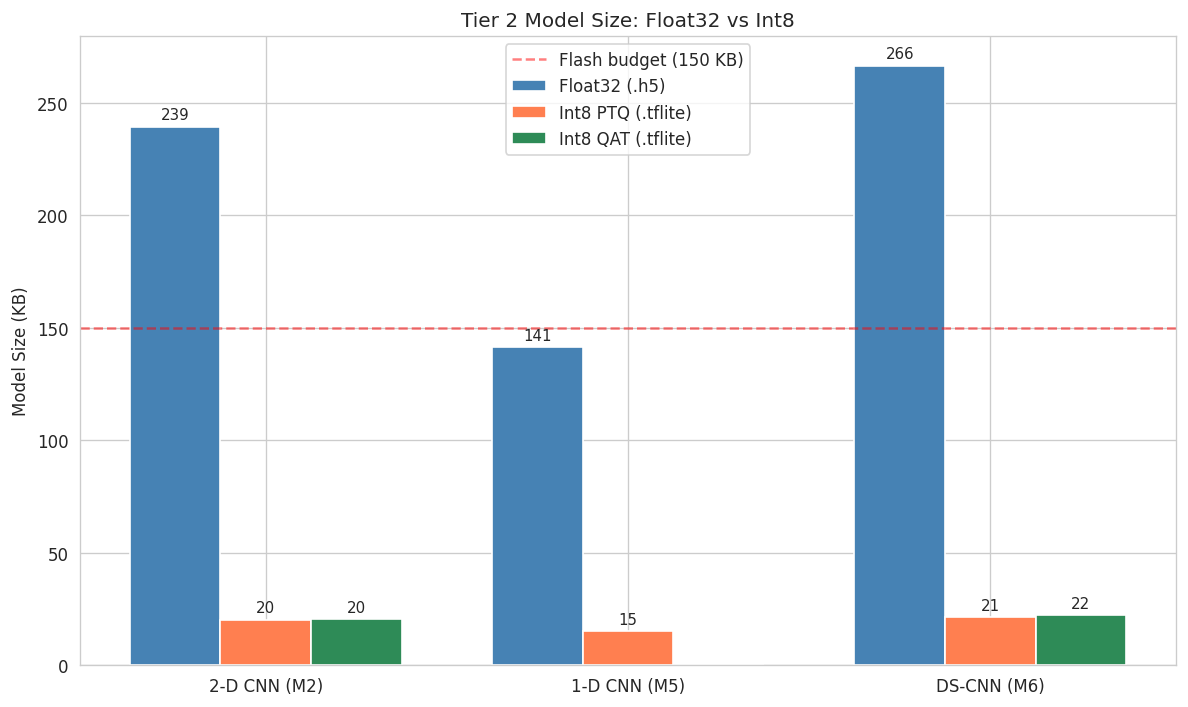


Compression ratios (Float32 .h5 -> Int8 PTQ .tflite):
  2-D CNN (M2): 239 KB -> 20.1 KB (11.9x compression)
  1-D CNN (M5): 141 KB -> 15.2 KB (9.3x compression)
  DS-CNN (M6): 266 KB -> 21.3 KB (12.5x compression)


In [4]:
# Model size comparison (Tier 2)
sizes = results['model_sizes']

fig, ax = plt.subplots(figsize=(10, 6))

models = ['m2', 'm5', 'm6']
labels = ['2-D CNN (M2)', '1-D CNN (M5)', 'DS-CNN (M6)']
x = np.arange(len(models))
width = 0.25

f32 = [sizes[m].get('tier2_f32_kb', 0) for m in models]
ptq = [sizes[m].get('tier2_ptq_kb', 0) for m in models]
qat = [sizes[m].get('tier2_qat_kb', 0) for m in models]

bars1 = ax.bar(x - width, f32, width, label='Float32 (.h5)', color='steelblue')
bars2 = ax.bar(x, ptq, width, label='Int8 PTQ (.tflite)', color='coral')
bars3 = ax.bar(x + width, qat, width, label='Int8 QAT (.tflite)', color='seagreen')

ax.set_ylabel('Model Size (KB)')
ax.set_title('Tier 2 Model Size: Float32 vs Int8')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(bar.get_x() + bar.get_width()/2, h + 2, f'{h:.0f}',
                    ha='center', va='bottom', fontsize=9)

ax.axhline(y=150, color='red', linestyle='--', alpha=0.5, label='Flash budget (150 KB)')
ax.legend()
plt.tight_layout()
plt.show()

# Compression ratios
print('\nCompression ratios (Float32 .h5 -> Int8 PTQ .tflite):')
for m, label in zip(models, labels):
    f = sizes[m].get('tier2_f32_kb', 1)
    p = sizes[m].get('tier2_ptq_kb', 1)
    print(f'  {label}: {f:.0f} KB -> {p:.1f} KB ({f/p:.1f}x compression)')

## 4. Model Size vs Accuracy Scatter Plot

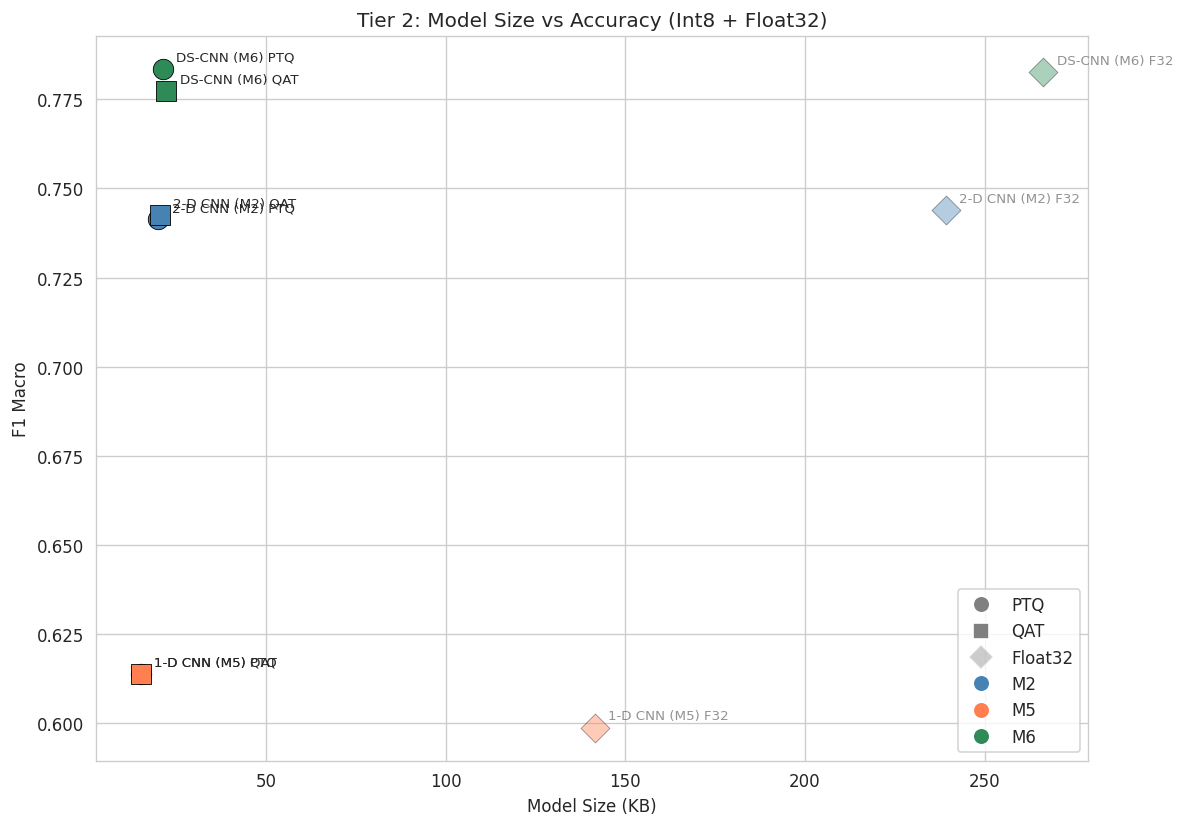

In [5]:
# Size vs accuracy scatter (Tier 2 only)
tier2 = df[df['tier'] == 2].copy()
tier2['display'] = tier2.apply(lambda r: f"{model_names[r['model']]} {r['method'].upper()}", axis=1)

fig, ax = plt.subplots(figsize=(10, 7))

colors = {'m2': 'steelblue', 'm5': 'coral', 'm6': 'seagreen'}
markers = {'ptq': 'o', 'qat': 's'}

for _, row in tier2.iterrows():
    ax.scatter(row['tflite_size_kb'], row['int8_f1_macro'],
               c=colors[row['model']], marker=markers[row['method']],
               s=150, edgecolors='black', linewidth=0.5, zorder=5)
    ax.annotate(row['display'], (row['tflite_size_kb'], row['int8_f1_macro']),
                textcoords='offset points', xytext=(8, 5), fontsize=8)

# Also plot float32 baselines
f32_baselines = results['float32_baselines']
for model in models:
    key = f'{model}_tier2'
    if key in f32_baselines:
        f32_size = sizes[model].get('tier2_f32_kb', 0)
        f32_f1 = f32_baselines[key]['f1_macro']
        ax.scatter(f32_size, f32_f1, c=colors[model], marker='D',
                   s=150, edgecolors='black', linewidth=0.5, alpha=0.4, zorder=4)
        ax.annotate(f'{model_names[model]} F32', (f32_size, f32_f1),
                    textcoords='offset points', xytext=(8, 5), fontsize=8, alpha=0.5)

ax.set_xlabel('Model Size (KB)')
ax.set_ylabel('F1 Macro')
ax.set_title('Tier 2: Model Size vs Accuracy (Int8 + Float32)')

# Custom legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='gray', markersize=10, label='PTQ'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='gray', markersize=10, label='QAT'),
    Line2D([0], [0], marker='D', color='w', markerfacecolor='gray', markersize=10, alpha=0.4, label='Float32'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='steelblue', markersize=10, label='M2'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='coral', markersize=10, label='M5'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='seagreen', markersize=10, label='M6'),
]
ax.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

## 5. Side-by-Side Confusion Matrices (Float32 vs Int8)

Comparing float32 and int8 PTQ confusion matrices for the best model (M6, Tier 2).

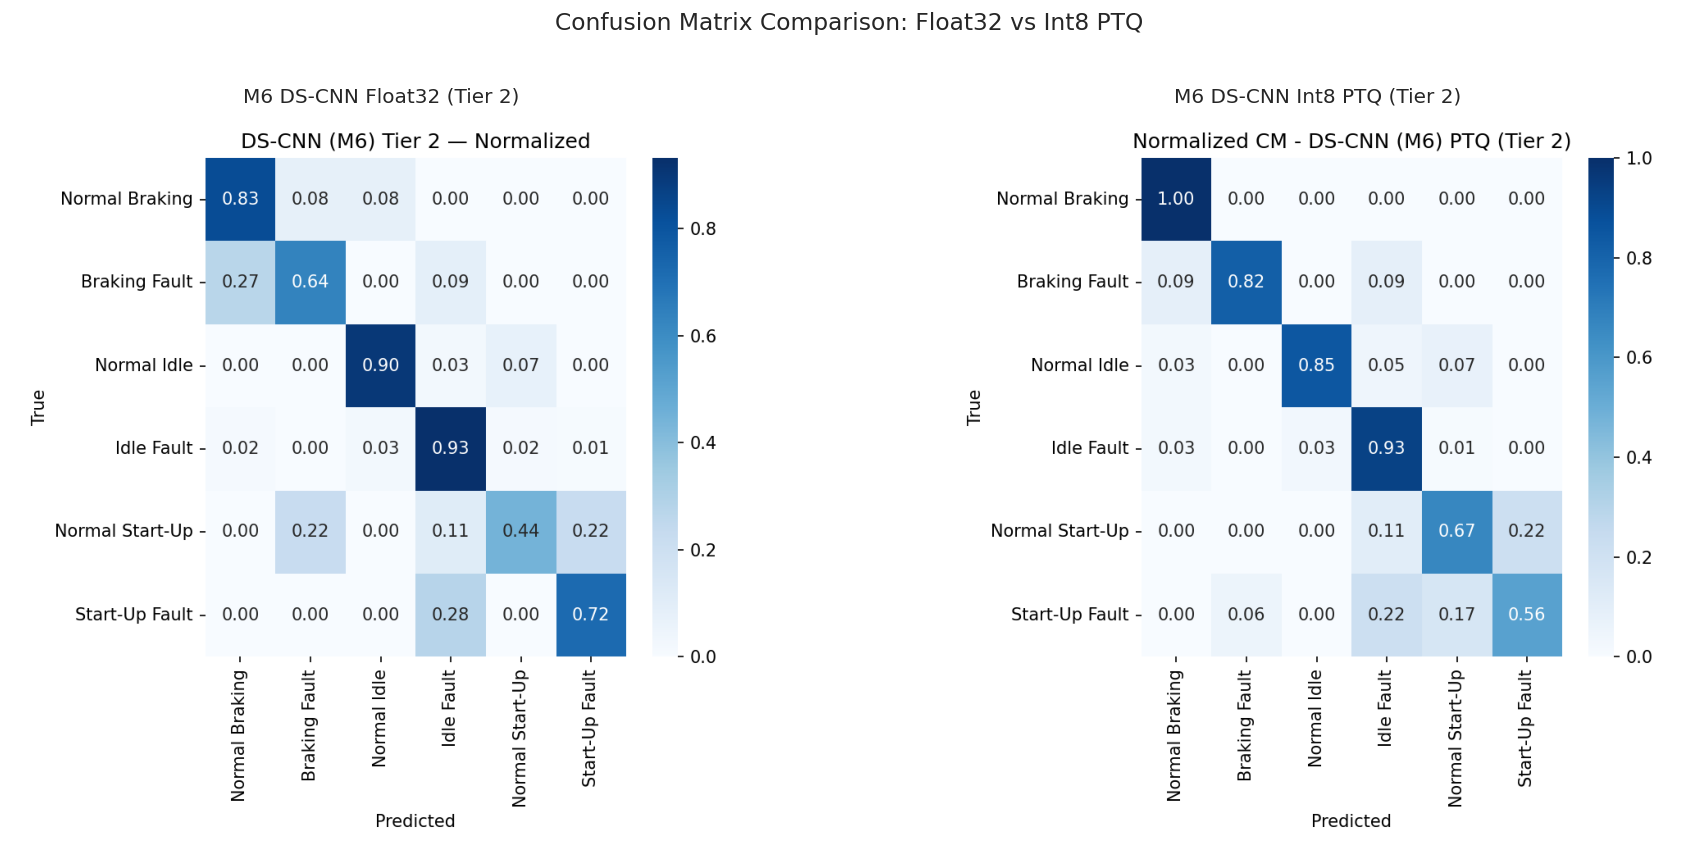

In [6]:
from PIL import Image

# Show float32 vs int8 confusion matrices side by side for M6 Tier 2
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Float32 CM (from Phase 3)
f32_cm_path = RESULTS_DIR / 'cm_m6_tier_2_norm.png'
if f32_cm_path.exists():
    img = Image.open(f32_cm_path)
    axes[0].imshow(img)
    axes[0].set_title('M6 DS-CNN Float32 (Tier 2)', fontsize=12)
    axes[0].axis('off')
else:
    axes[0].text(0.5, 0.5, 'Float32 CM not found', ha='center', va='center')
    axes[0].set_title('Float32')

# Int8 PTQ CM
int8_cm_path = RESULTS_DIR / 'cm_m6_ptq_tier_2_norm.png'
if int8_cm_path.exists():
    img = Image.open(int8_cm_path)
    axes[1].imshow(img)
    axes[1].set_title('M6 DS-CNN Int8 PTQ (Tier 2)', fontsize=12)
    axes[1].axis('off')
else:
    axes[1].text(0.5, 0.5, 'Int8 PTQ CM not found', ha='center', va='center')
    axes[1].set_title('Int8 PTQ')

plt.suptitle('Confusion Matrix Comparison: Float32 vs Int8 PTQ', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 6. Confidence Distribution Comparison

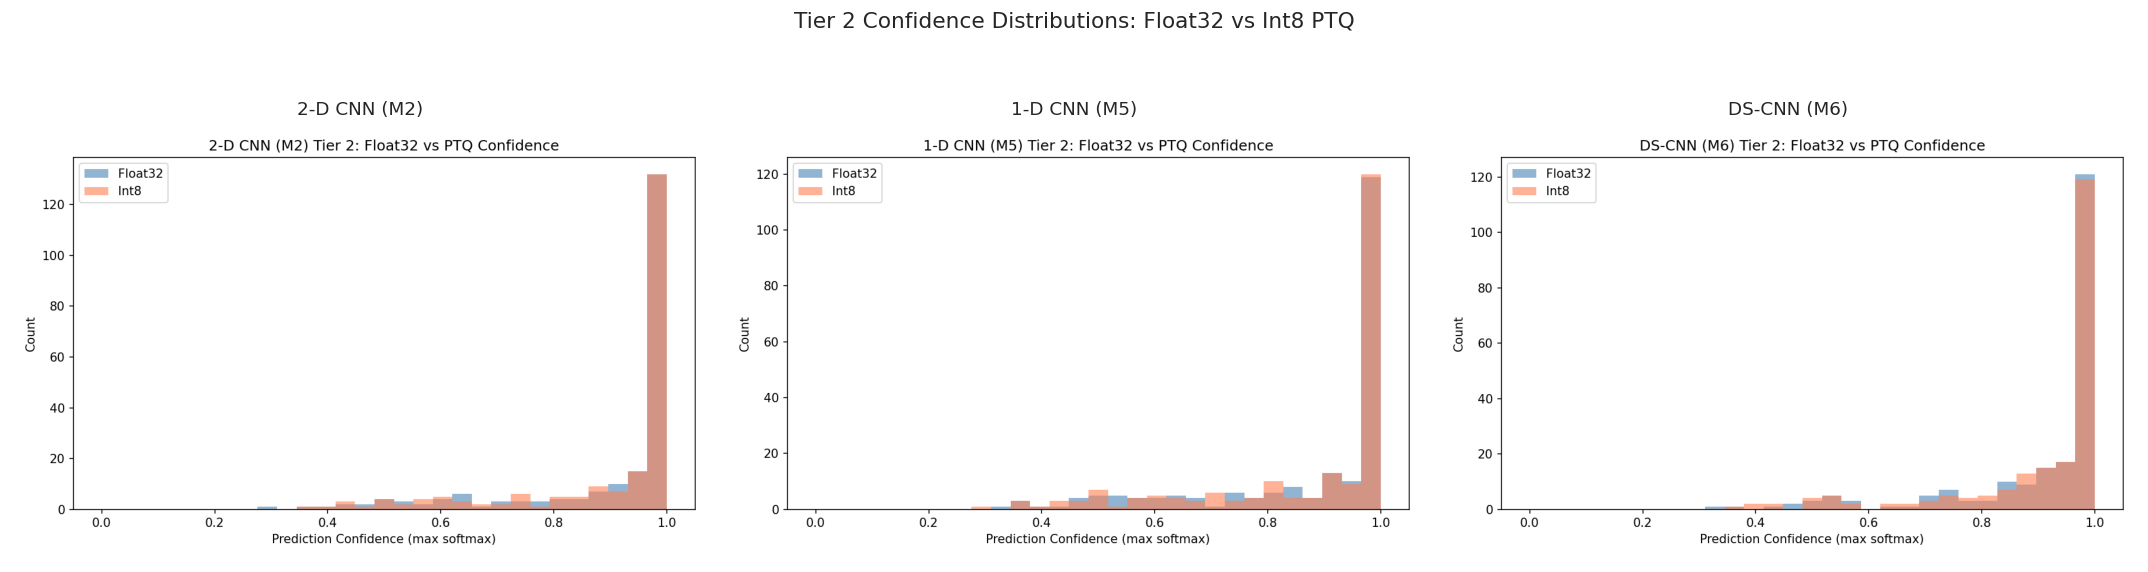


Confidence Distribution Statistics (Tier 2):
Model                Method  F32 Mean  F32 Std  Int8 Mean  Int8 Std   Shift
------------------------------------------------------------------------
2-D CNN (M2)         PTQ        0.908    0.160      0.908     0.155  -0.000
2-D CNN (M2)         QAT        0.908    0.160      0.907     0.150  -0.001
1-D CNN (M5)         PTQ        0.880    0.179      0.877     0.180  -0.002
1-D CNN (M5)         QAT        0.880    0.179      0.877     0.180  -0.002
DS-CNN (M6)          PTQ        0.910    0.145      0.908     0.145  -0.002
DS-CNN (M6)          QAT        0.910    0.145      0.908     0.149  -0.002


In [7]:
# Show confidence comparison plots generated by the script
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for i, (model, label) in enumerate(zip(['m2', 'm5', 'm6'], 
                                        ['2-D CNN (M2)', '1-D CNN (M5)', 'DS-CNN (M6)'])):
    img_path = RESULTS_DIR / f'confidence_{model}_tier2_ptq.png'
    if img_path.exists():
        img = Image.open(img_path)
        axes[i].imshow(img)
        axes[i].axis('off')
    else:
        axes[i].text(0.5, 0.5, f'{label}\nNot found', ha='center', va='center')
    axes[i].set_title(label, fontsize=11)

plt.suptitle('Tier 2 Confidence Distributions: Float32 vs Int8 PTQ', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Print confidence stats
print('\nConfidence Distribution Statistics (Tier 2):')
print(f'{"Model":<20} {"Method":<6} {"F32 Mean":>9} {"F32 Std":>8} {"Int8 Mean":>10} {"Int8 Std":>9} {"Shift":>7}')
print('-' * 72)
for key, r in sorted(results['quantized_models'].items()):
    if r['tier'] == 2:
        print(f'{model_names[r["model"]]:<20} {r["method"].upper():<6} '
              f'{r["impact_f32_mean_confidence"]:>9.3f} {r["impact_f32_std_confidence"]:>8.3f} '
              f'{r["impact_int8_mean_confidence"]:>10.3f} {r["impact_int8_std_confidence"]:>9.3f} '
              f'{r["impact_int8_mean_confidence"] - r["impact_f32_mean_confidence"]:>+7.3f}')

## 7. Per-Class Quantization Sensitivity

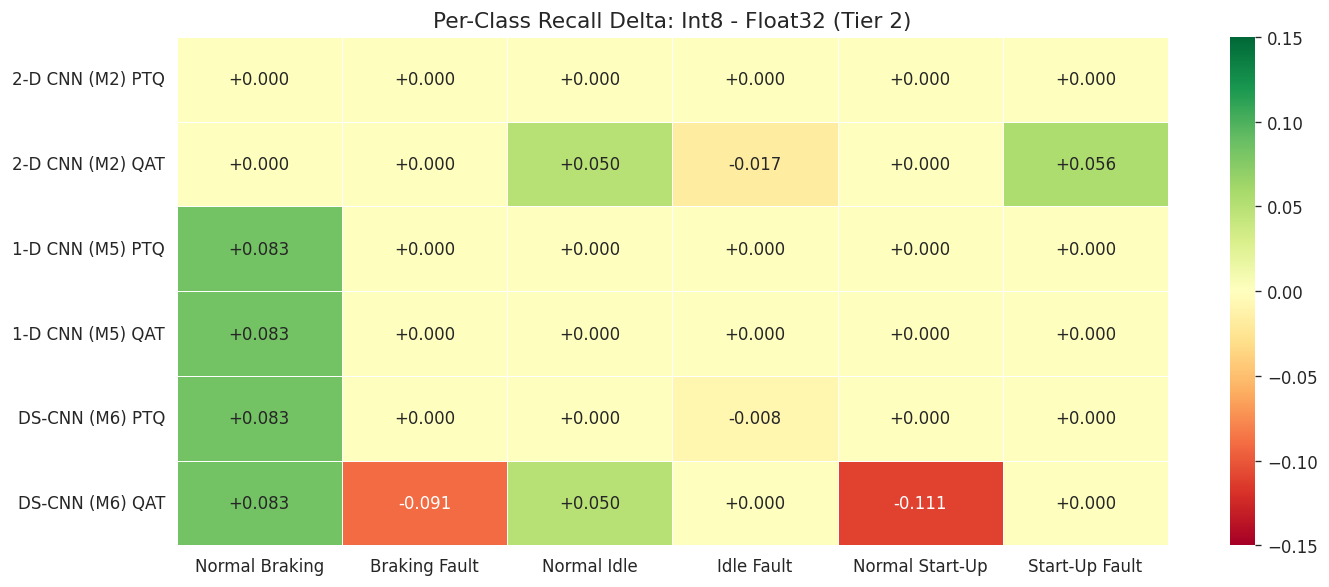


Note: Positive values mean int8 has HIGHER recall than float32.
Small values across the board confirm quantization is nearly lossless.


In [8]:
# Per-class recall delta heatmap for Tier 2
class_names = ['Normal Braking', 'Braking Fault', 'Normal Idle', 
               'Idle Fault', 'Normal Start-Up', 'Start-Up Fault']

# Build matrix
model_methods = []
delta_matrix = []

for key, r in sorted(results['quantized_models'].items()):
    if r['tier'] == 2:
        deltas = r.get('impact_per_class_recall_delta', [])
        if deltas:
            label = f"{model_names[r['model']]} {r['method'].upper()}"
            model_methods.append(label)
            delta_matrix.append(deltas)

delta_df = pd.DataFrame(delta_matrix, index=model_methods, columns=class_names)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(delta_df, annot=True, fmt='+.3f', cmap='RdYlGn', center=0,
            vmin=-0.15, vmax=0.15, ax=ax, linewidths=0.5)
ax.set_title('Per-Class Recall Delta: Int8 - Float32 (Tier 2)', fontsize=13)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

print('\nNote: Positive values mean int8 has HIGHER recall than float32.')
print('Small values across the board confirm quantization is nearly lossless.')

## 8. PTQ vs QAT Accuracy Drop

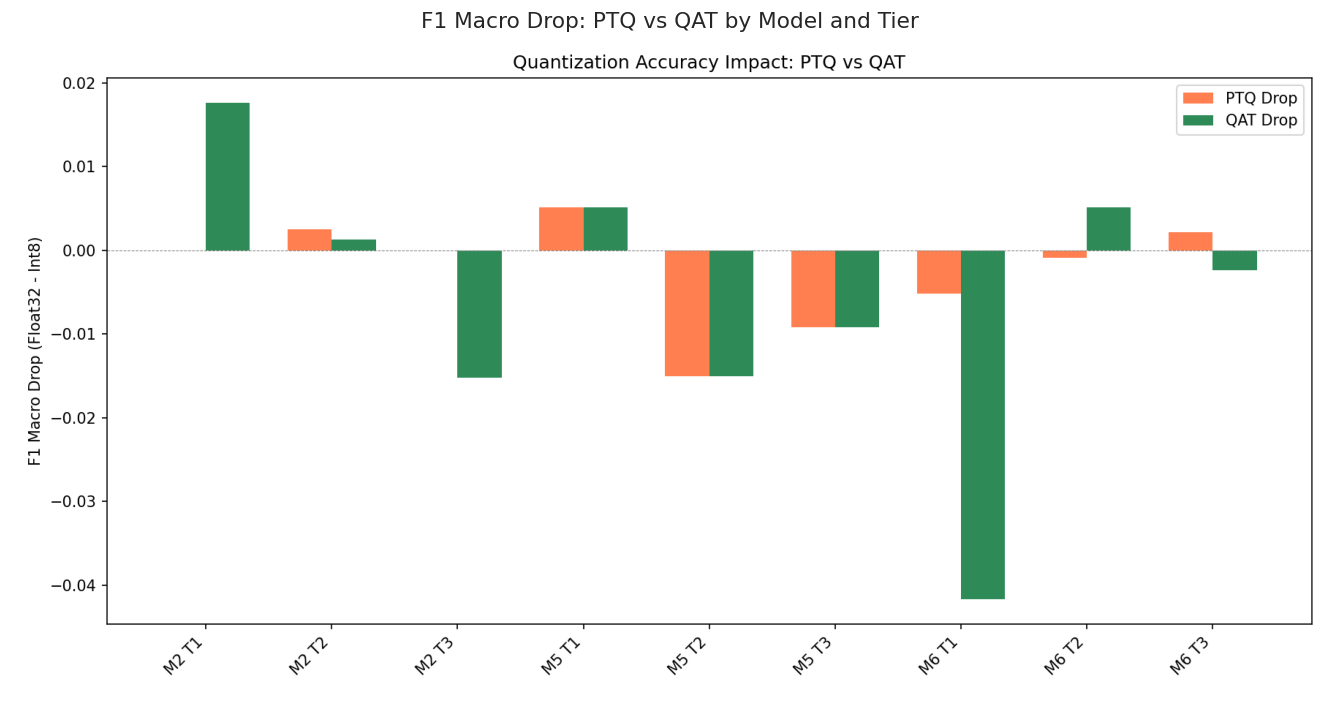


PTQ vs QAT F1 Macro Comparison (Tier 2):
Model                 F32 F1m  PTQ F1m  QAT F1m  PTQ wins?
----------------------------------------------------------
2-D CNN (M2)           0.7438   0.7413   0.7426        QAT
1-D CNN (M5)           0.5987   0.6138      N/A   PTQ only
DS-CNN (M6)            0.7826   0.7835   0.7774        PTQ


In [9]:
# Show the accuracy drop chart generated by the script
drop_path = RESULTS_DIR / 'quantization_accuracy_drop.png'
if drop_path.exists():
    img = Image.open(drop_path)
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.imshow(img)
    ax.axis('off')
    plt.title('F1 Macro Drop: PTQ vs QAT by Model and Tier', fontsize=13)
    plt.tight_layout()
    plt.show()

# Summary statistics
print('\nPTQ vs QAT F1 Macro Comparison (Tier 2):')
print(f'{"Model":<20} {"F32 F1m":>8} {"PTQ F1m":>8} {"QAT F1m":>8} {"PTQ wins?":>10}')
print('-' * 58)
for model in ['m2', 'm5', 'm6']:
    tier2_data = df[(df['model'] == model) & (df['tier'] == 2)]
    ptq = tier2_data[tier2_data['method'] == 'ptq'].iloc[0] if len(tier2_data[tier2_data['method'] == 'ptq']) > 0 else None
    qat = tier2_data[tier2_data['method'] == 'qat'].iloc[0] if len(tier2_data[tier2_data['method'] == 'qat']) > 0 else None
    
    f32_f1 = ptq['f32_f1_macro'] if ptq is not None else 0
    ptq_f1 = ptq['int8_f1_macro'] if ptq is not None else 0
    qat_f1 = qat['int8_f1_macro'] if qat is not None else 0
    
    qat_str = f'{qat_f1:>8.4f}' if model != 'm5' else '     N/A'
    winner = 'PTQ' if ptq_f1 >= qat_f1 else 'QAT'
    if model == 'm5':
        winner = 'PTQ only'
    
    print(f'{model_names[model]:<20} {f32_f1:>8.4f} {ptq_f1:>8.4f} {qat_str} {winner:>10}')

## 9. Deployment Recommendation

Final ranking of int8 models for Arduino Nano 33 BLE Sense Rev2 deployment.

In [10]:
# Deployment ranking (Tier 2)
tier2 = df[df['tier'] == 2].sort_values('int8_f1_macro', ascending=False)

arena_est = {'m2': '~70-80 KB', 'm5': '~15-25 KB', 'm6': '~35-45 KB'}

print('Deployment Ranking (Tier 2 - Primary Target)')
print('=' * 90)
print(f'{"Rank":<5} {"Model":<25} {"Method":<6} {"Int8 F1m":>9} {"Size":>8} {"Arena Est.":>12} {"Agreement":>10}')
print('-' * 90)

for rank, (_, row) in enumerate(tier2.iterrows(), 1):
    print(f'{rank:<5} {model_names[row["model"]]:<25} {row["method"].upper():<6} '
          f'{row["int8_f1_macro"]:>9.4f} {row["tflite_size_kb"]:>7.1f}KB '
          f'{arena_est[row["model"]]:>12} {row["agreement_rate"]:>10.1%}')

print(f'\n{"=" * 90}')
print('RECOMMENDATION: M6 DS-CNN PTQ (Rank 1)')
print('  - Highest Tier 2 F1 macro (0.7835)')
print('  - 21.3 KB model, ~35-45 KB arena -- comfortable fit on Arduino')
print('  - 98.6% prediction agreement with float32 -- quantization barely changes behavior')
print('  - PTQ is simpler than QAT (no fine-tuning) and performs equally well')

Deployment Ranking (Tier 2 - Primary Target)
Rank  Model                     Method  Int8 F1m     Size   Arena Est.  Agreement
------------------------------------------------------------------------------------------
1     DS-CNN (M6)               PTQ       0.7835    21.3KB    ~35-45 KB      98.6%
2     DS-CNN (M6)               QAT       0.7774    22.3KB    ~35-45 KB      95.2%
3     2-D CNN (M2)              QAT       0.7426    20.5KB    ~70-80 KB      95.7%
4     2-D CNN (M2)              PTQ       0.7413    20.1KB    ~70-80 KB      99.0%
5     1-D CNN (M5)              PTQ       0.6138    15.2KB    ~15-25 KB      99.0%
6     1-D CNN (M5)              QAT       0.6138    15.2KB    ~15-25 KB      99.0%

RECOMMENDATION: M6 DS-CNN PTQ (Rank 1)
  - Highest Tier 2 F1 macro (0.7835)
  - 21.3 KB model, ~35-45 KB arena -- comfortable fit on Arduino
  - 98.6% prediction agreement with float32 -- quantization barely changes behavior
  - PTQ is simpler than QAT (no fine-tuning) and performs 

## 10. Key Takeaways

1. **Quantization is nearly lossless.** No statistically significant accuracy change across any of the 15 model-tier-method combinations (all McNemar p > 0.05).

2. **PTQ is sufficient for these models.** QAT fine-tuning adds complexity without measurable benefit. The small model sizes (6K-15K parameters) and BatchNorm folding leave minimal quantization error for QAT to correct.

3. **M6 DS-CNN PTQ is the deployment champion.** Best accuracy (F1=0.7835), comfortable hardware fit (21 KB, ~40 KB arena), and CMSIS-NN optimized kernels on Cortex-M4.

4. **Confidence calibration is preserved.** Mean confidence shift < 0.002 for all models, meaning float32 confidence thresholds can be used directly with int8 models.

5. **Conv1D QAT is unsupported** in tfmot 0.8.0. M5 uses PTQ only, which works well.